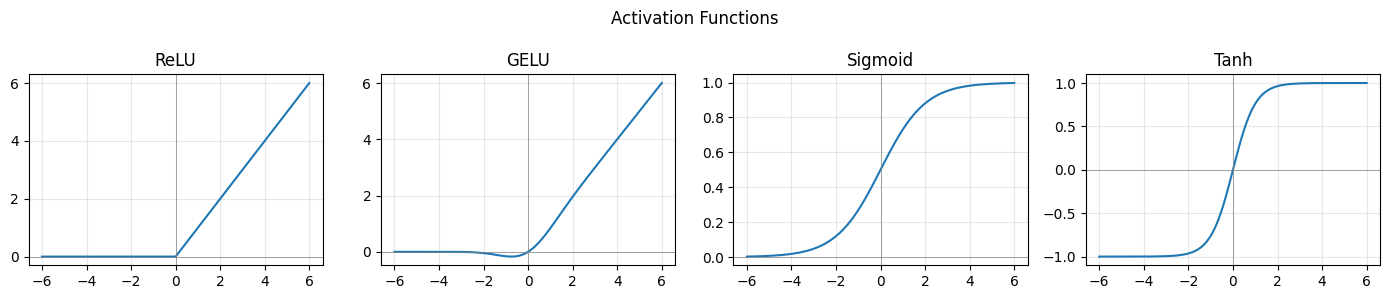

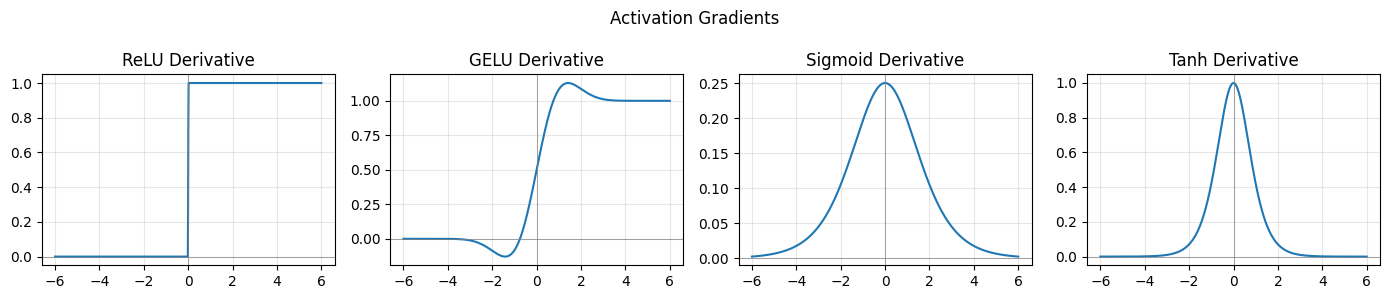

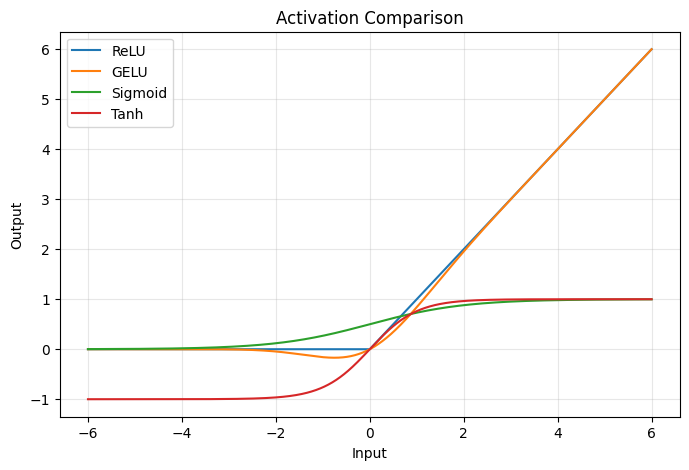

In [9]:
x = np.linspace(-6, 6, 1000)

# Activations
relu = np.maximum(0, x)

gelu = x * 0.5 * (
    1 + np.tanh(
        np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)
    )
)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

activations = {
    "ReLU": relu,
    "GELU": gelu,
    "Sigmoid": sigmoid,
    "Tanh": tanh,
}

# Numerical derivatives
derivatives = {
    name: np.gradient(y, x)
    for name, y in activations.items()
}

# --------------------------------------------------
# Figure 1: Activations
# --------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x, y)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.suptitle("Activation Functions")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Figure 2: Derivatives
# --------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for ax, (name, dy) in zip(axes, derivatives.items()):
    ax.plot(x, dy)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(f"{name} Derivative")
    ax.grid(alpha=0.3)

plt.suptitle("Activation Gradients")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Figure 3: Overlay Comparison
# --------------------------------------------------
plt.figure(figsize=(8, 5))

for name, y in activations.items():
    plt.plot(x, y, label=name)

plt.title("Activation Comparison")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

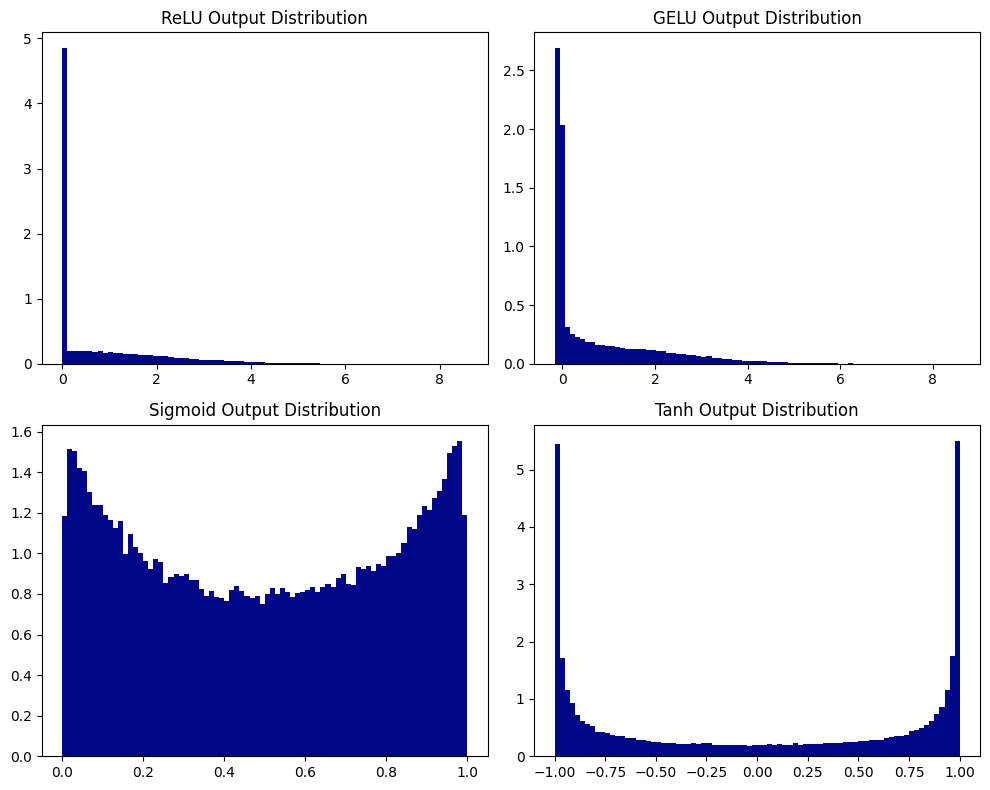

In [12]:
# Random neuron inputs
inputs = np.random.normal(0, 2, 100000)

outputs = {
    "ReLU": np.maximum(0, inputs),
    "GELU": inputs * 0.5 * (
        1 + np.tanh(
            np.sqrt(2 / np.pi) *
            (inputs + 0.044715 * inputs**3)
        )
    ),
    "Sigmoid": 1 / (1 + np.exp(-inputs)),
    "Tanh": np.tanh(inputs),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, out) in zip(axes.ravel(), outputs.items()):
    ax.hist(out, bins=80, density=True, color='#000888')
    ax.set_title(f"{name} Output Distribution")

plt.tight_layout()
plt.show()

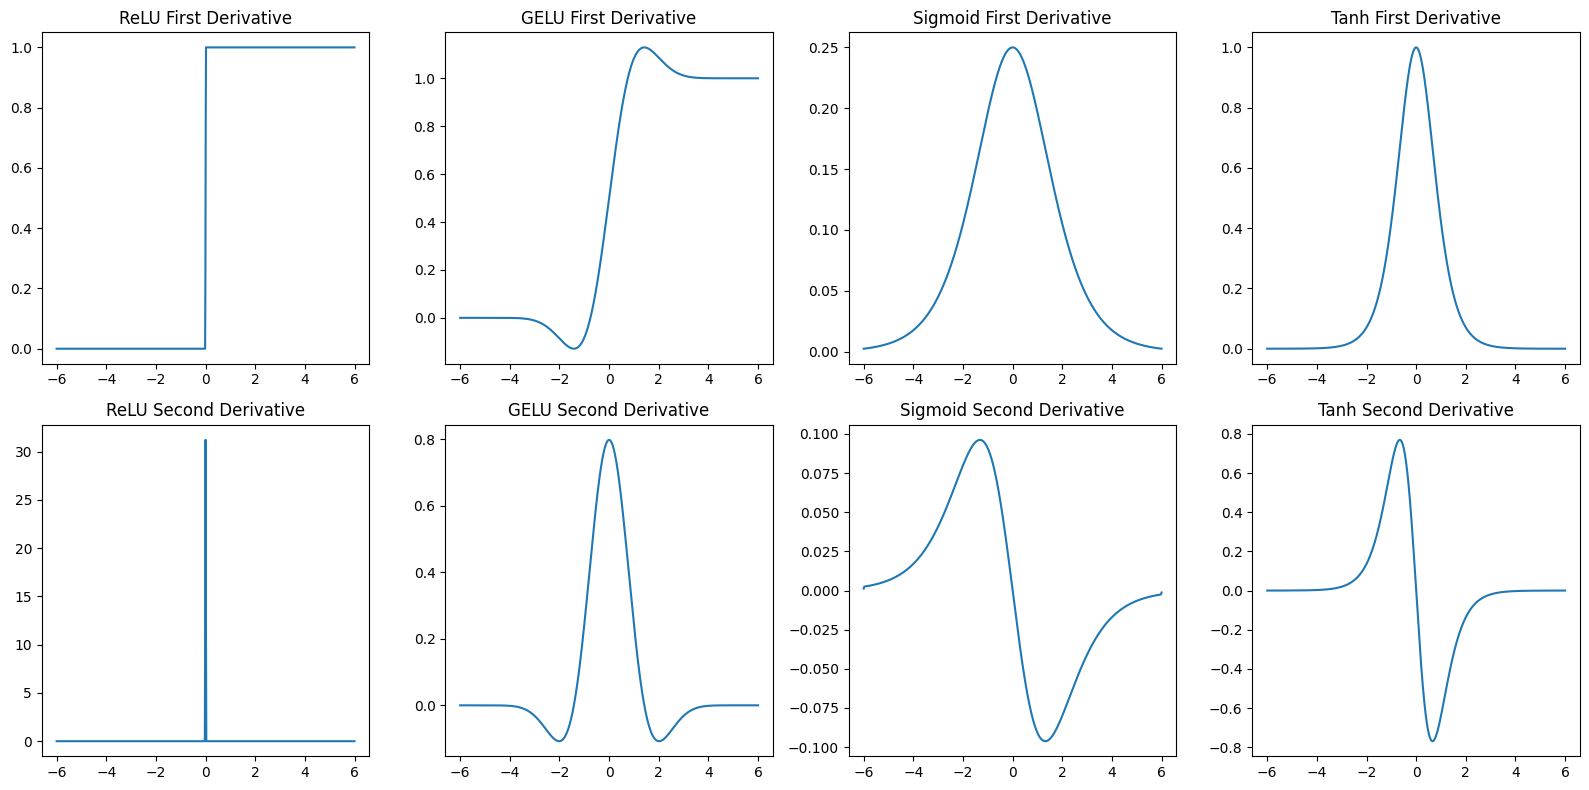

In [13]:
def first_derivative(y, x):
    return np.gradient(y, x)

def second_derivative(y, x):
    return np.gradient(first_derivative(y, x), x)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (name, y) in enumerate(activations.items()):

    dy = first_derivative(y, x)
    d2y = second_derivative(y, x)

    axes[0, col].plot(x, dy)
    axes[0, col].set_title(f"{name} First Derivative")

    axes[1, col].plot(x, d2y)
    axes[1, col].set_title(f"{name} Second Derivative")

plt.tight_layout()
plt.show()

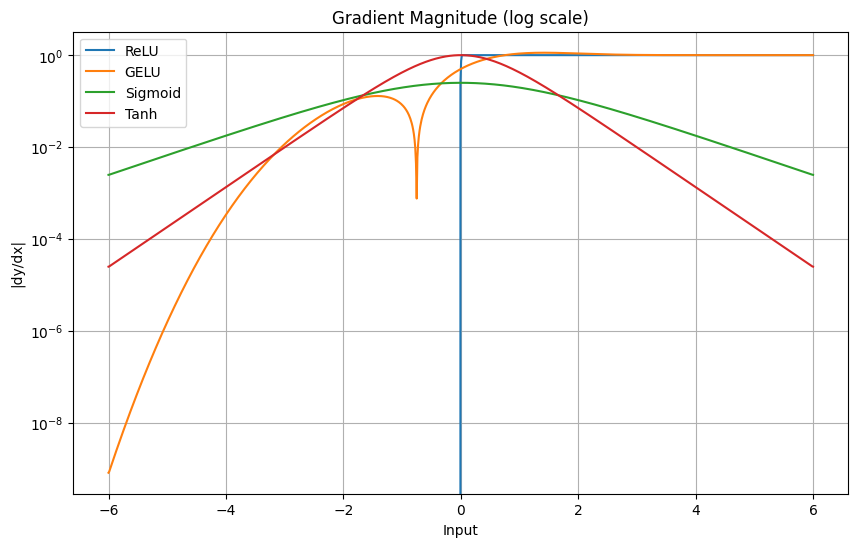

In [14]:
plt.figure(figsize=(10, 6))

for name, y in activations.items():
    dy = np.abs(np.gradient(y, x))
    plt.semilogy(x, dy, label=name)

plt.title("Gradient Magnitude (log scale)")
plt.xlabel("Input")
plt.ylabel("|dy/dx|")
plt.legend()
plt.grid()
plt.show()

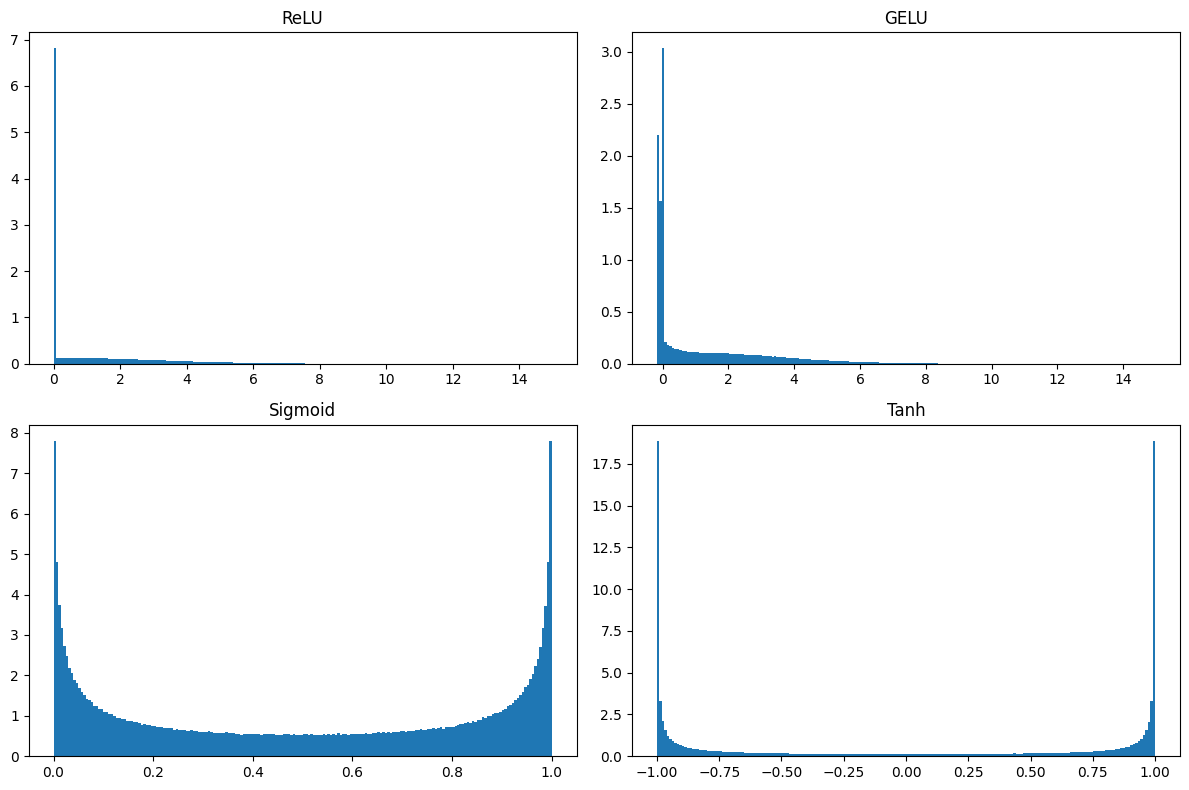

In [15]:
inputs = np.random.normal(0, 3, size=1_000_000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (name, _) in zip(axes.ravel(), activations.items()):

    if name == "ReLU":
        out = np.maximum(0, inputs)

    elif name == "GELU":
        out = inputs * 0.5 * (
            1 + np.tanh(
                np.sqrt(2/np.pi)*(inputs + 0.044715*inputs**3)
            )
        )

    elif name == "Sigmoid":
        out = 1/(1+np.exp(-inputs))

    elif name == "Tanh":
        out = np.tanh(inputs)

    ax.hist(out, bins=200, density=True)
    ax.set_title(name)

plt.tight_layout()
plt.show()

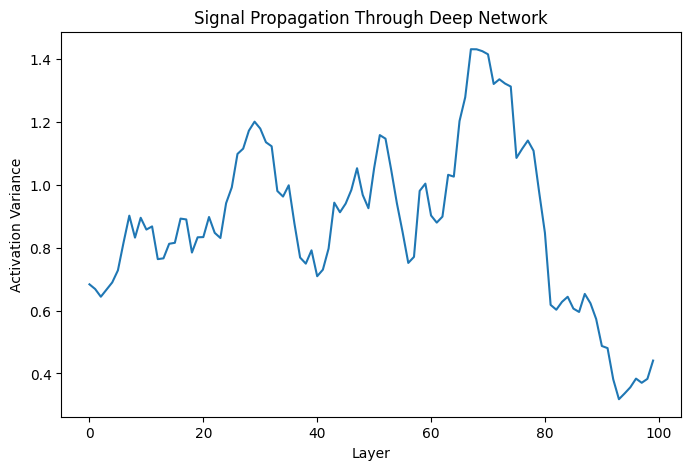

In [16]:
layers = 100
width = 512

x = np.random.normal(size=(1000, width))

variances = []

for _ in range(layers):

    W = np.random.normal(
        scale=np.sqrt(2/width),
        size=(width, width)
    )

    x = x @ W

    x = np.maximum(0, x)   # swap activation here

    variances.append(np.var(x))

plt.figure(figsize=(8, 5))
plt.plot(variances)
plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Signal Propagation Through Deep Network")
plt.show()

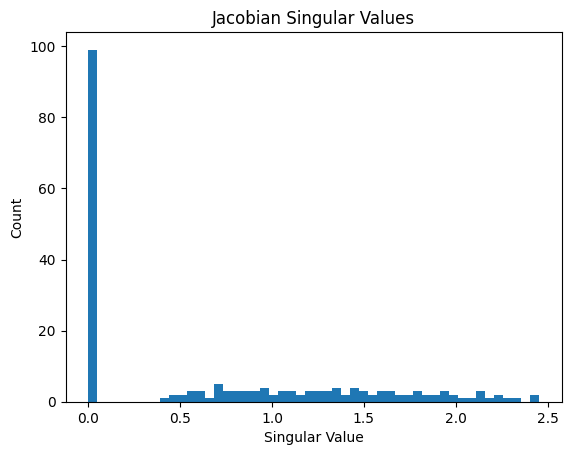

In [17]:
n = 200

W = np.random.normal(
    scale=np.sqrt(2/n),
    size=(n, n)
)

x = np.random.normal(size=n)

relu_grad = (x > 0).astype(float)

J = np.diag(relu_grad) @ W

s = np.linalg.svd(J, compute_uv=False)

plt.hist(s, bins=50)
plt.title("Jacobian Singular Values")
plt.xlabel("Singular Value")
plt.ylabel("Count")
plt.show()

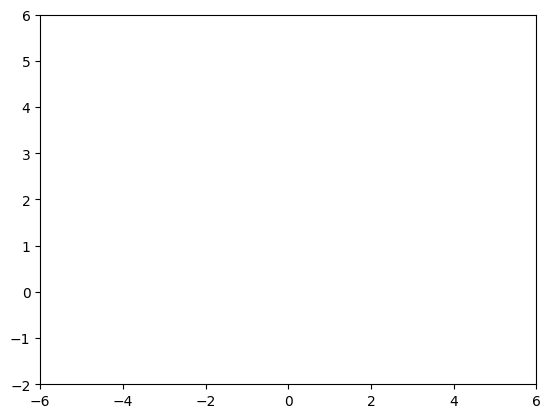

In [19]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

line, = ax.plot([], [])

ax.set_xlim(-6, 6)
ax.set_ylim(-2, 6)

def update(scale):

    y = np.maximum(0, scale * x)

    line.set_data(x, y)

    return line,

ani = FuncAnimation(
    fig,
    update,
    frames=np.linspace(0.1, 3, 100),
    interval=50
)

plt.show()

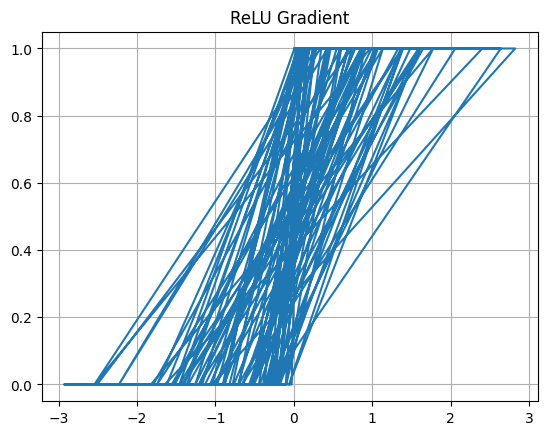

In [20]:
relu = np.maximum(0, x)
relu_grad = np.where(x > 0, 1, 0)

plt.plot(x, relu_grad)
plt.title("ReLU Gradient")
plt.grid()
plt.show()

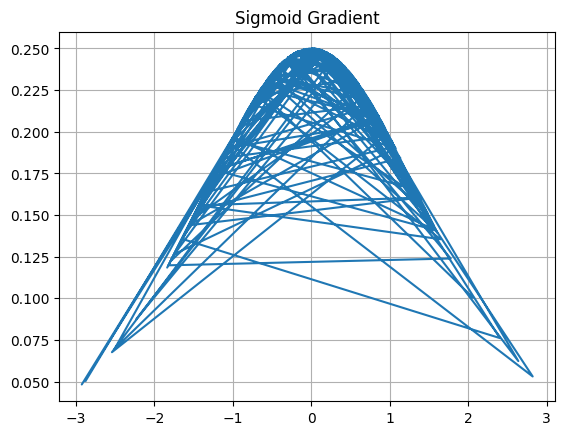

In [21]:
sigmoid = 1/(1+np.exp(-x))
sigmoid_grad = sigmoid * (1 - sigmoid)

plt.plot(x, sigmoid_grad)
plt.title("Sigmoid Gradient")
plt.grid()
plt.show()

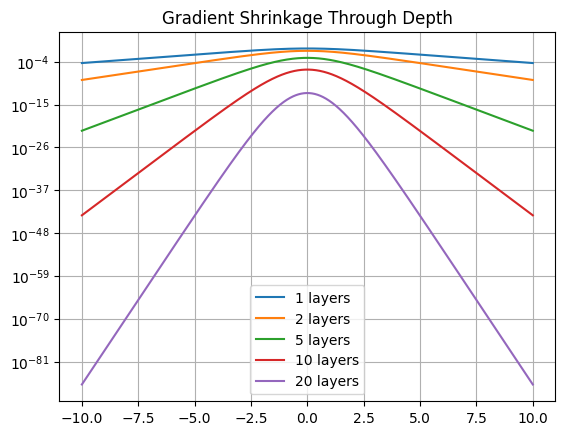

In [22]:
x = np.linspace(-10, 10, 1000)

sigmoid = 1/(1+np.exp(-x))
grad = sigmoid * (1-sigmoid)

for depth in [1, 2, 5, 10, 20]:

    total_grad = grad**depth

    plt.plot(
        x,
        total_grad,
        label=f"{depth} layers"
    )

plt.yscale("log")
plt.legend()
plt.grid()
plt.title("Gradient Shrinkage Through Depth")
plt.show()